In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("stock_4_train.csv")
test_df = pd.read_csv("stock_4_test.csv")

In [3]:
df

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,col_10,col_11,target
0,0.424029,0.295219,-0.024097,-0.435836,-0.002699,0.472895,-0.861135,1.437132,0.687150,-2.405460,-0.224154,0.652256,234.741806
1,0.373265,-0.495269,0.450540,-1.699891,-0.293396,0.156919,0.169310,0.699030,-0.244469,0.447642,-0.069460,-0.853122,234.561167
2,-0.666127,1.142011,1.068544,-0.445941,0.029668,-0.473709,0.545722,-0.194471,-0.417481,0.046179,-1.582216,-0.600940,219.871537
3,-1.358564,1.935897,-1.479647,-2.264622,-1.446383,-0.137873,-1.337771,-0.562608,-2.033435,1.087469,0.419872,1.648708,243.878038
4,-0.602635,0.312738,-0.083550,0.982916,0.448874,0.219763,-1.493817,-0.453126,-0.976579,-0.447180,-0.825892,-0.243687,223.868846
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9994,-1.208201,-1.679255,1.119114,-0.124294,3.014765,0.967003,1.371236,-0.944311,-0.083793,0.808683,-0.084175,0.709805,266.718012
9995,0.958317,0.398045,-1.474446,0.518469,-0.726606,2.327907,-0.863907,-0.997090,-2.256624,-0.840100,0.652148,1.981307,245.089371
9996,0.204721,0.166237,-1.042708,-0.736244,-0.025199,-0.365617,0.820588,-0.420785,0.887081,-0.361778,0.023931,-1.425207,248.127000
9997,-0.035335,-0.348299,0.831558,1.162337,1.084188,-1.185472,1.304911,-0.357935,-0.755030,-0.169328,0.831128,-3.391316,241.731172


In [4]:
df.describe()

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,col_10,col_11,target
count,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000
mean,0.002576,0.009001,-0.014513,0.006801,0.009664,0.013754,-0.015334,-0.010659,-0.005731,-0.017937,-0.003238,0.012286,245.396866
std,1.006690,1.011676,1.004826,1.013451,0.987040,0.997522,1.006001,1.007861,0.998665,1.011963,0.994023,1.334833,27.765682
min,-3.516856,-3.810019,-3.888142,-3.887804,-3.427947,-3.377759,-4.257009,-3.597631,-3.530409,-3.906788,-3.584981,-5.691738,80.000000
25%,-0.677030,-0.663188,-0.682174,-0.667004,-0.652701,-0.653680,-0.698079,-0.697162,-0.680728,-0.697701,-0.675224,-0.867982,235.721903
50%,-0.000247,0.000386,-0.022317,0.006761,-0.008795,0.010628,-0.018980,-0.027102,-0.013416,-0.016647,-0.009811,0.030292,243.717579
75%,0.664378,0.687635,0.663164,0.690668,0.664554,0.676651,0.661696,0.661307,0.669804,0.675333,0.661113,0.883611,254.095244
max,3.498573,4.185392,4.087923,4.085418,4.506746,5.007235,3.623629,4.326921,3.667378,4.151241,3.759615,5.604084,400.000000


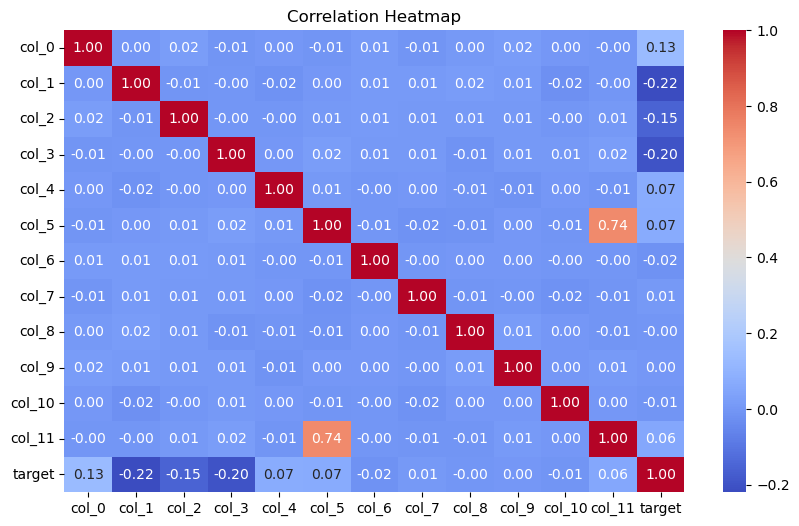

In [5]:
corr = df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

multicollinearity between column 5 and 11 but thats it

In [6]:
df.corr()['target']

col_0     0.131019
col_1    -0.219770
col_2    -0.153342
col_3    -0.197521
col_4     0.073548
col_5     0.069566
col_6    -0.016526
col_7     0.007620
col_8    -0.004140
col_9     0.000883
col_10   -0.007611
col_11    0.055734
target    1.000000
Name: target, dtype: float64

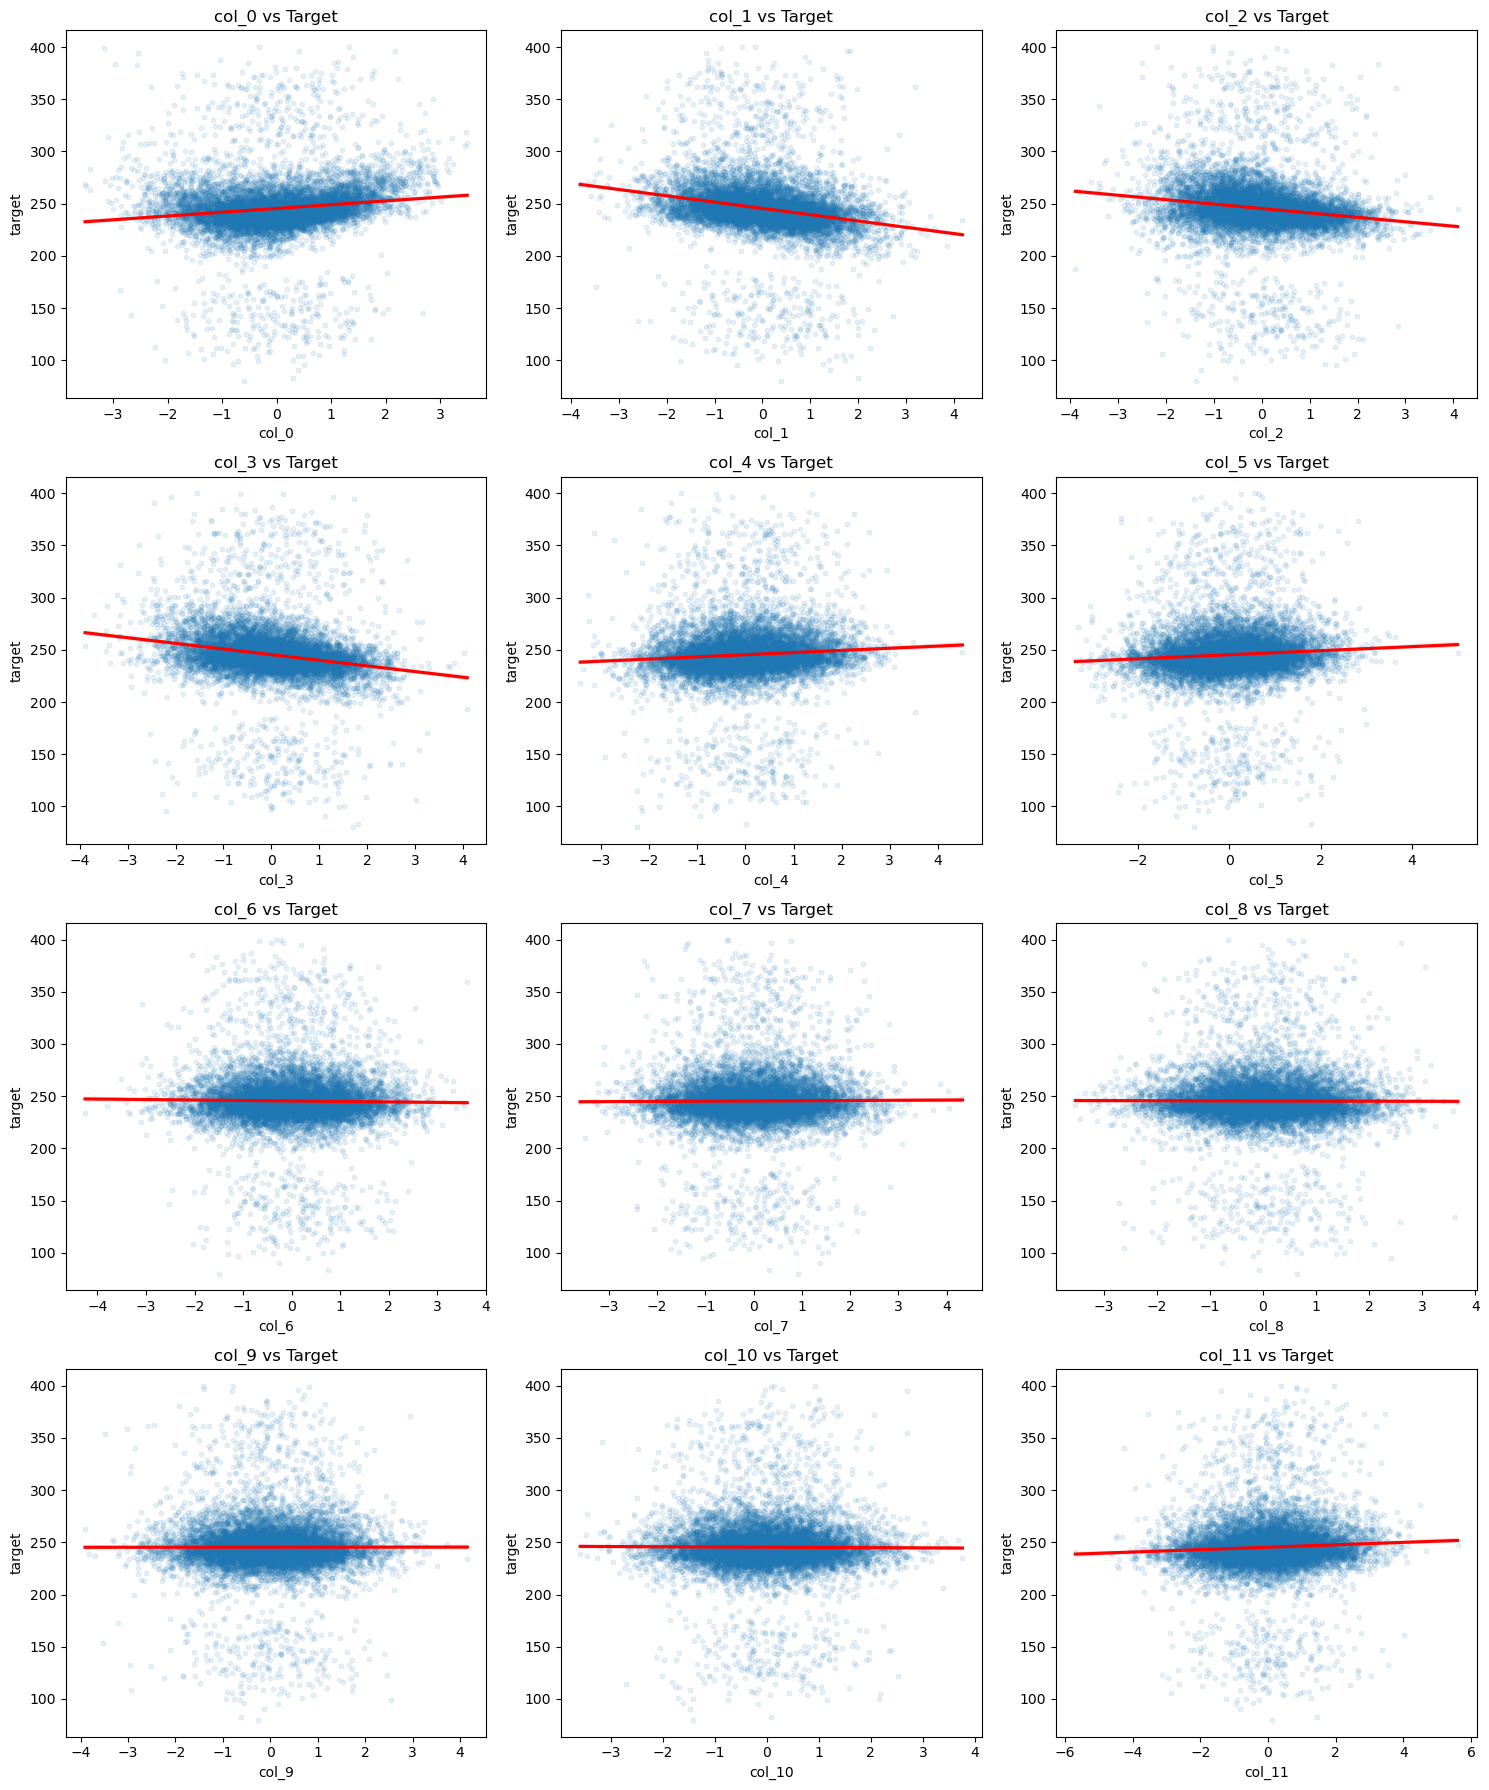

In [7]:
# List of your original columns (excluding the ones we created)
features = [col for col in df.columns if col.startswith('col_')]

# Create a grid of subplots
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 18))
axes = axes.flatten()

for i, col in enumerate(features):
    # sns.regplot adds a 'best fit' line automatically to help see linearity
    sns.regplot(x=df[col], y=df['target'], ax=axes[i], 
                scatter_kws={'alpha':0.1, 's':10}, # Make dots transparent to see density
                line_kws={'color':'red'})
    axes[i].set_title(f'{col} vs Target')

plt.tight_layout()
plt.show()

## col_0

In [8]:
df['col_0_cut'] = pd.qcut(df['col_0'], 8)

In [9]:
stats_df = df.groupby("col_0_cut", observed=True)['target'].agg(['mean', 'median', 'std', 'count', 'min', 'max'])

stats_df['noise_ratio'] = stats_df['std'] / stats_df['mean']

stats_df

,mean,median,std,count,min,max,noise_ratio
col_0_cut,,,,,,,
"(-3.518, -1.148]",247.037664,244.969732,29.969990,1250,100.444009,398.861664,0.121317
"(-1.148, -0.677]",240.681505,240.472367,26.005103,1250,96.625944,387.105786,0.108048
"(-0.677, -0.319]",241.339803,240.195785,28.077443,1250,80.000000,400.000000,0.116340
"(-0.319, -0.000247]",240.678029,240.756143,26.157329,1250,108.087829,380.406845,0.108682
"(-0.000247, 0.311]",242.664294,240.981801,24.909455,1249,83.190306,379.201865,0.102650
"(0.311, 0.664]",244.003462,243.323878,27.147393,1250,90.608970,396.392780,0.111258
"(0.664, 1.171]",248.289687,245.734230,27.030396,1250,105.325142,385.316024,0.108866
"(1.171, 3.499]",258.478299,256.590119,27.996349,1250,106.067086,399.744790,0.108312


In [10]:
bins = [-4, -1.148, 1.171, 3.5]
labels = ['low_outlier', 'middle', 'high_outlier']

df['col_0_group'] = pd.cut(df['col_0'], bins=bins, labels=labels, right=True)

C:\Users\kiera\AppData\Local\Temp\ipykernel_9116\3942615984.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='col_0_group', y='target', palette='viridis')


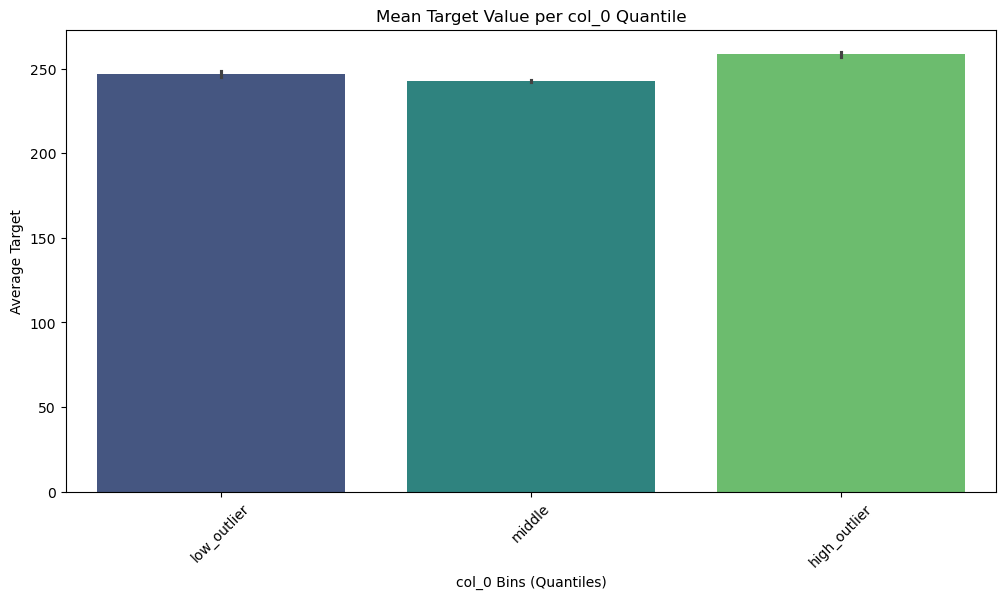

In [11]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='col_0_group', y='target', palette='viridis')
plt.title('Mean Target Value per col_0 Quantile')
plt.xlabel('col_0 Bins (Quantiles)')
plt.ylabel('Average Target')
plt.xticks(rotation=45)
plt.show()

## col_1

In [12]:
df['col_1_cut'] = pd.qcut(df['col_1'], 8)

In [13]:
stats_df = df.groupby("col_1_cut", observed=True)['target'].agg(['mean', 'median', 'std', 'count', 'min', 'max'])

stats_df['noise_ratio'] = stats_df['std'] / stats_df['mean']

stats_df

,mean,median,std,count,min,max,noise_ratio
col_1_cut,,,,,,,
"(-3.811, -1.143]",254.973593,252.208544,28.526480,1250,99.441810,394.739583,0.111880
"(-1.143, -0.663]",250.939806,247.646825,27.975552,1250,106.728605,398.861664,0.111483
"(-0.663, -0.312]",248.343865,245.922288,26.317647,1250,95.350017,400.000000,0.105973
"(-0.312, 0.000386]",246.474590,244.636355,25.745598,1250,101.073173,399.744790,0.104455
"(0.000386, 0.327]",246.012438,243.054279,24.740675,1249,103.920310,385.046013,0.100567
"(0.327, 0.688]",242.473868,241.192391,26.744164,1250,80.000000,373.257273,0.110297
"(0.688, 1.168]",239.194386,239.518606,26.035458,1250,106.049475,390.756231,0.108846
"(1.168, 4.185]",234.762875,235.696870,30.358236,1250,83.190306,396.608345,0.129314


C:\Users\kiera\AppData\Local\Temp\ipykernel_9116\735921143.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='col_1_cut', y='target', palette='viridis')


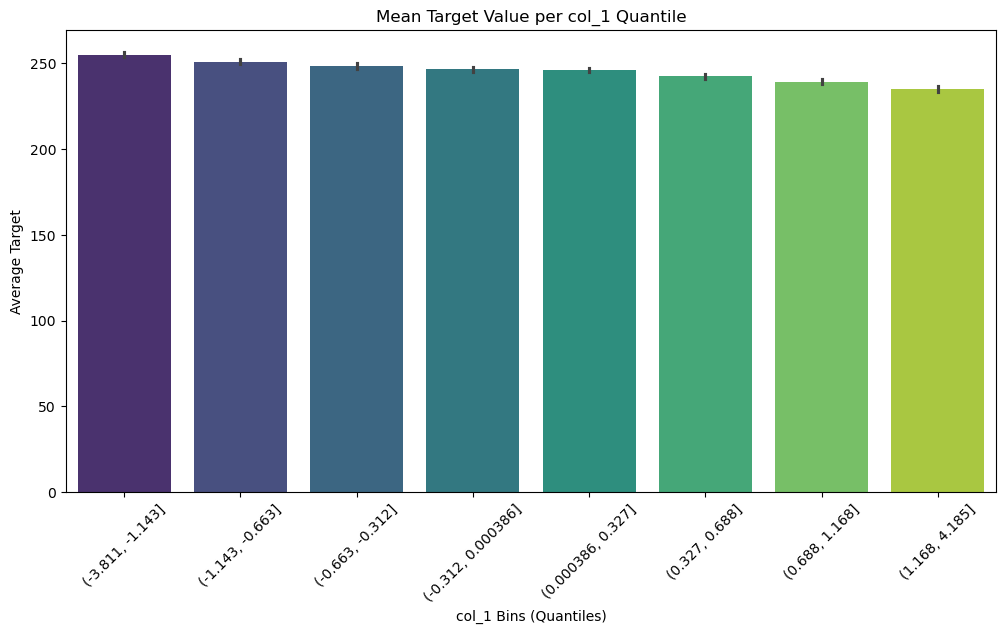

In [14]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='col_1_cut', y='target', palette='viridis')
plt.title('Mean Target Value per col_1 Quantile')
plt.xlabel('col_1 Bins (Quantiles)')
plt.ylabel('Average Target')
plt.xticks(rotation=45)
plt.show()

In [15]:
df['col_1_0_interaction'] = df['col_1'] - df['col_0']

df[['col_1', 'col_0', 'col_1_0_interaction', 'target']].corr()['target']

col_1                 -0.219770
col_0                  0.131019
col_1_0_interaction   -0.248513
target                 1.000000
Name: target, dtype: float64

increase of +3% with the interaction feature.

## col_2

In [16]:
df['col_2_cut'] = pd.qcut(df['col_2'], 8)

In [17]:
stats_df = df.groupby("col_2_cut", observed=True)['target'].agg(['mean', 'median', 'std', 'count', 'min', 'max'])

stats_df['noise_ratio'] = stats_df['std'] / stats_df['mean']

stats_df

,mean,median,std,count,min,max,noise_ratio
col_2_cut,,,,,,,
"(-3.889, -1.183]",251.902095,249.782165,30.795922,1250,80.000000,400.000000,0.122254
"(-1.183, -0.682]",249.267077,247.389226,29.538907,1250,99.173776,399.744790,0.118503
"(-0.682, -0.34]",248.210733,246.307315,27.616966,1250,83.190306,394.739583,0.111264
"(-0.34, -0.0223]",246.680474,244.990644,25.557491,1250,107.102954,387.105786,0.103606
"(-0.0223, 0.293]",244.955516,244.170383,27.004086,1249,99.763724,390.756231,0.110241
"(0.293, 0.663]",243.019694,242.147602,27.845136,1250,104.413135,398.861664,0.114580
"(0.663, 1.148]",240.495471,240.931589,24.242335,1250,103.920310,377.088928,0.100802
"(1.148, 4.088]",238.643517,238.522944,26.461637,1250,95.350017,383.305012,0.110884


C:\Users\kiera\AppData\Local\Temp\ipykernel_9116\2372868189.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='col_2_cut', y='target', palette='viridis')


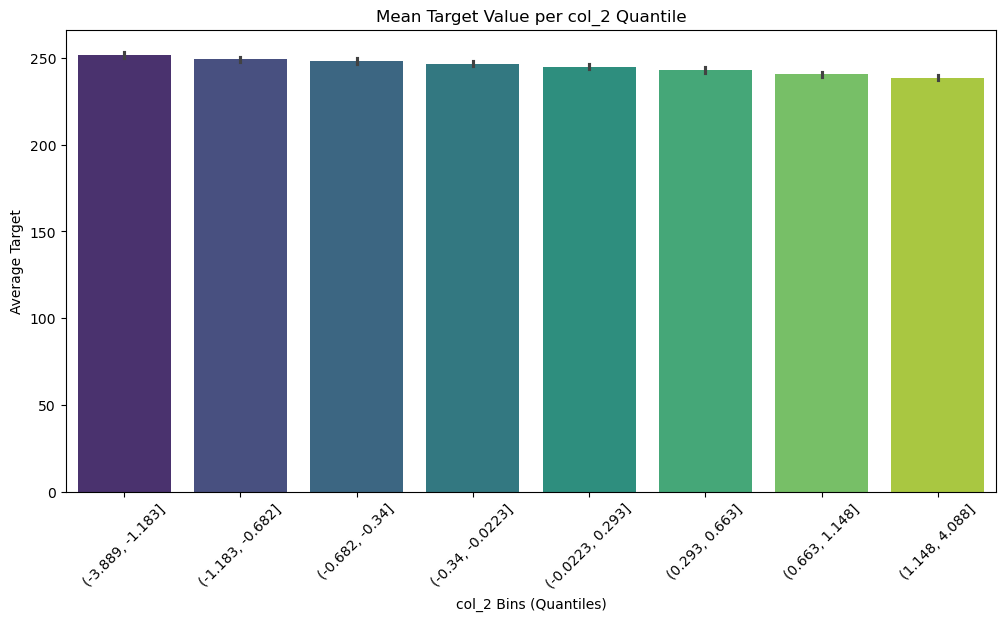

In [18]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='col_2_cut', y='target', palette='viridis')
plt.title('Mean Target Value per col_2 Quantile')
plt.xlabel('col_2 Bins (Quantiles)')
plt.ylabel('Average Target')
plt.xticks(rotation=45)
plt.show()

In [19]:
# Create a copy to avoid SettingWithCopy warnings
df_feats = df.copy()

# 1. Basic Arithmetic (Linear Combinations)
df_feats['1_plus_2'] = df_feats['col_1'] + df_feats['col_2']
df_feats['1_minus_2'] = df_feats['col_1'] - df_feats['col_2']
df_feats['1_minus_0'] = df_feats['col_1'] - df_feats['col_0']
df_feats['2_minus_0'] = df_feats['col_2'] - df_feats['col_0']
df_feats['1_plus_2_minus_0'] = df_feats['col_1'] + df_feats['col_2'] - df_feats['col_0']

# 2. Squared Differences (Captures 'distance' or magnitude)
df_feats['1_minus_2_sq'] = (df_feats['col_1'] - df_feats['col_2'])**2
df_feats['1_minus_0_sq'] = (df_feats['col_1'] - df_feats['col_0'])**2

# 3. Product Interactions (Magnifies when both are large)
df_feats['1_times_2'] = df_feats['col_1'] * df_feats['col_2']
df_feats['1_times_0'] = df_feats['col_1'] * df_feats['col_0']

# 4. Log Transforms (Compresses outliers/long tails)
# Adding a small constant to avoid log(0) or log(negative)
offset = abs(df_feats[['col_0', 'col_1', 'col_2']].min().min()) + 1
df_feats['log_1'] = np.log(df_feats['col_1'] + offset)
df_feats['log_2'] = np.log(df_feats['col_2'] + offset)

# 5. Ratios (How one moves relative to the other)
df_feats['ratio_1_2'] = df_feats['col_1'] / (df_feats['col_2'] + offset)

# Evaluation: Calculate Correlations
all_new_cols = [c for c in df_feats.columns if c not in df.columns or c in ['col_0', 'col_1', 'col_2']]
correlations = df_feats[all_new_cols + ['target']].corr()['target'].sort_values(ascending=False)

print("--- Feature Correlation Leaderboard ---")
print(correlations)

--- Feature Correlation Leaderboard ---
target              1.000000
1_times_0           0.146083
col_0               0.131019
1_times_2           0.072324
1_minus_0_sq       -0.007426
1_minus_2          -0.047688
1_minus_2_sq       -0.058776
log_2              -0.151650
col_2              -0.153342
2_minus_0          -0.203432
log_1              -0.213377
col_1              -0.219770
ratio_1_2          -0.231760
1_minus_0          -0.248513
1_plus_2           -0.264989
1_plus_2_minus_0   -0.294498
Name: target, dtype: float64


Take the **most important features here**, or take all of the features and do a ridge regression. Can also experiment with sqrt, cubic features etc.

In [20]:
df["1_plus_2_minus_0"] = df["col_1"] + df["col_2"] - df["col_0"]
df["ratio_1_2"] = df["col_1"] / df["col_2"]

## col_3

In [21]:
df['col_3_cut'] = pd.qcut(df['col_3'], 8)

In [22]:
stats_df = df.groupby("col_3_cut", observed=True)['target'].agg(['mean', 'median', 'std', 'count', 'min', 'max'])

stats_df['noise_ratio'] = stats_df['std'] / stats_df['mean']

stats_df

,mean,median,std,count,min,max,noise_ratio
col_3_cut,,,,,,,
"(-3.889, -1.167]",255.005155,252.350905,29.370588,1250,95.350017,400.000000,0.115176
"(-1.167, -0.667]",249.562801,247.680204,26.764776,1250,104.413135,385.316024,0.107247
"(-0.667, -0.303]",248.720189,246.755652,26.171780,1250,108.623099,399.744790,0.105226
"(-0.303, 0.00676]",245.730273,244.485871,26.985020,1250,96.625944,377.368529,0.109816
"(0.00676, 0.34]",244.450949,243.479269,27.381382,1249,99.441810,398.861664,0.112012
"(0.34, 0.691]",241.901723,241.331033,25.951715,1250,103.920310,383.305012,0.107282
"(0.691, 1.17]",241.600113,240.638626,25.602876,1250,90.608970,382.529235,0.105972
"(1.17, 4.085]",236.202969,237.066662,29.458824,1250,80.000000,396.608345,0.124718


C:\Users\kiera\AppData\Local\Temp\ipykernel_9116\2252809598.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='col_3_cut', y='target', palette='viridis')


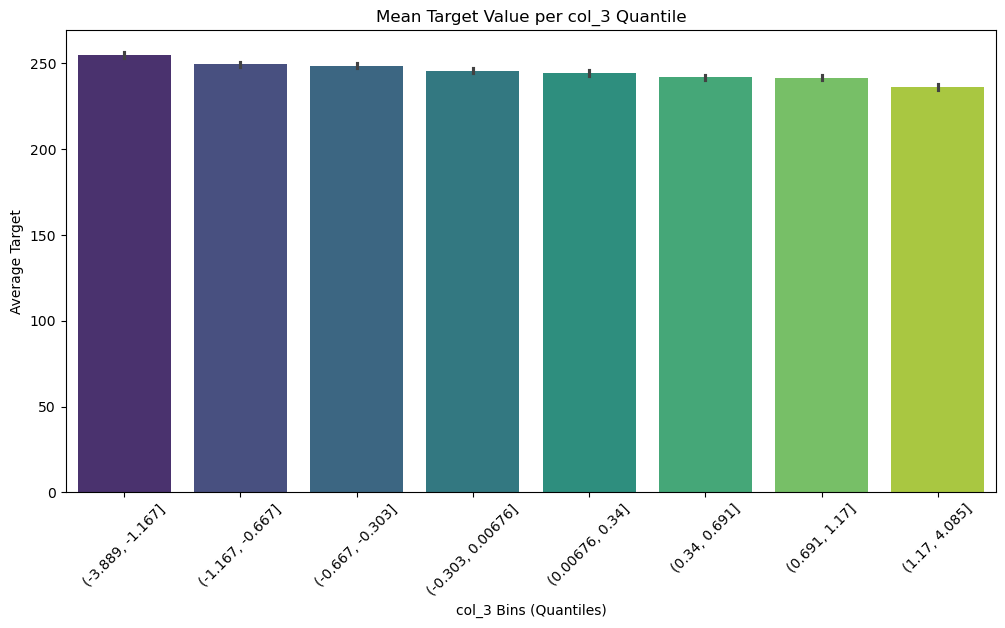

In [23]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='col_3_cut', y='target', palette='viridis')
plt.title('Mean Target Value per col_3 Quantile')
plt.xlabel('col_3 Bins (Quantiles)')
plt.ylabel('Average Target')
plt.xticks(rotation=45)
plt.show()

In [24]:
# 1. Create a copy and handle the offset for logs/ratios
df_feats = df.copy()
offset = abs(df_feats[['col_0', 'col_1', 'col_2', 'col_3']].min().min()) + 1

# --- GROUP 1: LINEAR COMBINATIONS (The "Summed Signal") ---
# Since 1, 2, 3 are negative-correlated and 0 is positive, 
# subtracting 0 and adding the others aligns their 'push' on the target.
df_feats['sum_123'] = df_feats['col_1'] + df_feats['col_2'] + df_feats['col_3']
df_feats['sum_123_minus_0'] = df_feats['sum_123'] - df_feats['col_0']
df_feats['avg_123'] = df_feats['sum_123'] / 3
df_feats['diff_1_3'] = df_feats['col_1'] - df_feats['col_3']
df_feats['diff_2_3'] = df_feats['col_2'] - df_feats['col_3']

# --- GROUP 2: PRODUCTS & MAGNITUDE (The "Amplifiers") ---
df_feats['1_times_2'] = df_feats['col_1'] * df_feats['col_2']
df_feats['1_times_3'] = df_feats['col_1'] * df_feats['col_3']
df_feats['2_times_3'] = df_feats['col_2'] * df_feats['col_3']
df_feats['123_product'] = df_feats['col_1'] * df_feats['col_2'] * df_feats['col_3']
df_feats['1_times_0'] = df_feats['col_1'] * df_feats['col_0']
df_feats['3_times_0'] = df_feats['col_3'] * df_feats['col_0']

# --- GROUP 3: NON-LINEAR / SQUARED (The "Distance" check) ---
df_feats['1_minus_3_sq'] = (df_feats['col_1'] - df_feats['col_3'])**2
df_feats['2_minus_3_sq'] = (df_feats['col_2'] - df_feats['col_3'])**2
df_feats['0_sq'] = df_feats['col_0']**2 # Testing if the 'U' shape is purely quadratic

# --- GROUP 4: RATIOS & GEOMETRY ---
df_feats['ratio_1_3'] = df_feats['col_1'] / (df_feats['col_3'] + offset)
df_feats['ratio_2_3'] = df_feats['col_2'] / (df_feats['col_3'] + offset)
df_feats['ratio_sum12_3'] = (df_feats['col_1'] + df_feats['col_2']) / (df_feats['col_3'] + offset)

# --- GROUP 5: LOG TRANSFORMS (Curve Flattening) ---
df_feats['log_3'] = np.log(df_feats['col_3'] + offset)
df_feats['log_123_sum'] = np.log(df_feats['sum_123'] + (offset * 3))

# --- EVALUATION ---
# Define which columns are "new" to avoid cluttering the leaderboard
all_cols = df_feats.columns
original_cols = ['col_0', 'col_1', 'col_2', 'col_3', 'target']
engineered_cols = [c for c in all_cols if c not in original_cols]

# Calculate correlations
correlations = df_feats.corr(numeric_only=True)['target'].sort_values(ascending=False)

print("--- Feature Correlation Leaderboard ---")
print(correlations)

--- Feature Correlation Leaderboard ---
target                 1.000000
0_sq                   0.208889
2_times_3              0.185520
1_times_0              0.146083
col_0                  0.131019
col_4                  0.073548
1_times_2              0.072324
col_5                  0.069566
col_11                 0.055734
diff_2_3               0.032239
123_product            0.011665
1_minus_3_sq           0.009144
col_7                  0.007620
ratio_1_2              0.005836
col_9                  0.000883
col_8                 -0.004140
3_times_0             -0.005505
col_10                -0.007611
diff_1_3              -0.015453
col_6                 -0.016526
1_times_3             -0.020991
2_minus_3_sq          -0.122753
col_2                 -0.153342
ratio_2_3             -0.190845
log_3                 -0.195866
col_3                 -0.197521
ratio_1_3             -0.208961
col_1                 -0.219770
col_1_0_interaction   -0.248513
ratio_sum12_3         -0.283687


In [25]:
df['sum_123_minus_0'] = (df['col_1'] + df['col_2'] + df['col_3']) - df['col_0']

offset = abs(df[['col_1', 'col_2', 'col_3']].min().min()) + 1

df['0_sq'] = df['col_0']**2

df['2_times_3'] = df['col_2'] * df['col_3']

df['ratio_sum12_3'] = (df['col_1'] + df['col_2']) / (df['col_3'] + offset)

## col_4

In [26]:
df['col_4_cut'] = pd.qcut(df['col_4'], 8)

In [27]:
stats_df = df.groupby("col_4_cut", observed=True)['target'].agg(['mean', 'median', 'std', 'count', 'min', 'max'])

stats_df['noise_ratio'] = stats_df['std'] / stats_df['mean']

stats_df

,mean,median,std,count,min,max,noise_ratio
col_4_cut,,,,,,,
"(-3.429, -1.116]",242.154882,241.084143,30.471138,1250,80.000000,400.000000,0.125833
"(-1.116, -0.653]",244.073715,242.234905,26.785796,1250,90.608970,384.369033,0.109745
"(-0.653, -0.316]",244.830934,243.188368,25.952938,1250,96.625944,398.861664,0.106004
"(-0.316, -0.00879]",244.076516,243.063571,26.081393,1250,105.325142,396.608345,0.106857
"(-0.00879, 0.308]",245.460537,243.801687,26.030924,1249,83.190306,374.735452,0.106049
"(0.308, 0.665]",247.015549,244.666069,30.814767,1250,103.920310,396.392780,0.124748
"(0.665, 1.172]",246.260284,245.297992,27.950325,1250,108.623099,379.881962,0.113499
"(1.172, 4.507]",249.302565,246.426723,27.029482,1250,103.992971,399.744790,0.108420


C:\Users\kiera\AppData\Local\Temp\ipykernel_9116\2945123859.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='col_4_cut', y='target', palette='viridis')


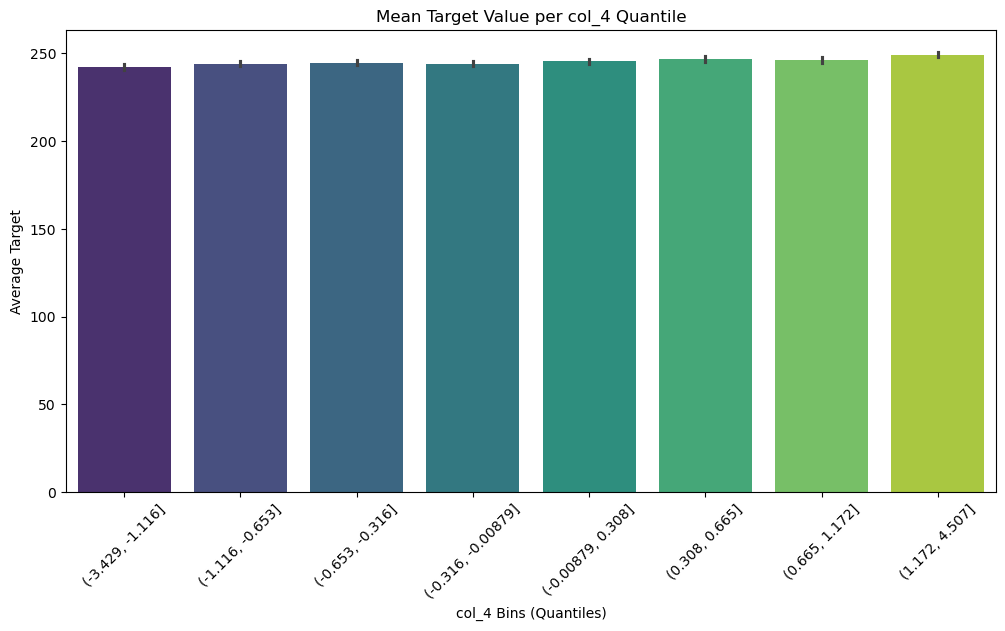

In [28]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='col_4_cut', y='target', palette='viridis')
plt.title('Mean Target Value per col_4 Quantile')
plt.xlabel('col_4 Bins (Quantiles)')
plt.ylabel('Average Target')
plt.xticks(rotation=45)
plt.show()

In [29]:
# 1. Create a copy and handle the offset
df_feats = df.copy()
# We include col_4 in the offset calculation now
cols_to_use = ['col_0', 'col_1', 'col_2', 'col_3', 'col_4']
offset = abs(df_feats[cols_to_use].min().min()) + 1

# --- GROUP 1: LINEAR COMBINATIONS (The "Global Trend") ---
# 1,2,3 are Negative | 0,4 are Positive (relative to target)
# Formula: (Positive Factors) - (Negative Factors)
df_feats['sum_all_linear'] = (df_feats['col_4'] - df_feats['col_0']) - (df_feats['col_1'] + df_feats['col_2'] + df_feats['col_3'])
df_feats['staircase_123'] = df_feats['col_1'] + df_feats['col_2'] + df_feats['col_3']
df_feats['staircase_1234'] = df_feats['staircase_123'] - df_feats['col_4'] # 4 is opposite direction
df_feats['diff_4_0'] = df_feats['col_4'] - df_feats['col_0']

# --- GROUP 2: NON-LINEAR & SQUARED (The "Intensity" check) ---
df_feats['col_0_sq'] = df_feats['col_0']**2
df_feats['col_4_sq'] = df_feats['col_4']**2
df_feats['col_1_sq'] = df_feats['col_1']**2
df_feats['quad_04'] = df_feats['col_0']**2 + df_feats['col_4']**2
df_feats['interaction_14'] = df_feats['col_1'] * df_feats['col_4']

# --- GROUP 3: COMPLEX INTERACTIONS (The "Amplifiers") ---
df_feats['prod_123'] = df_feats['col_1'] * df_feats['col_2'] * df_feats['col_3']
df_feats['prod_all'] = df_feats['prod_123'] * df_feats['col_4'] * df_feats['col_0']
df_feats['mag_123'] = np.sqrt(df_feats['col_1']**2 + df_feats['col_2']**2 + df_feats['col_3']**2)

# --- GROUP 4: RATIOS (The "Relative Strength") ---
# How does col_4 (upward) compare to the downward pressure of the others?
df_feats['ratio_4_1'] = df_feats['col_4'] / (df_feats['col_1'] + offset)
df_feats['ratio_4_sum123'] = df_feats['col_4'] / (df_feats['staircase_123'] + (offset * 3))
df_feats['ratio_12_34'] = (df_feats['col_1'] + df_feats['col_2']) / (df_feats['col_3'] + df_feats['col_4'] + (offset * 2))

# --- GROUP 5: LOGS & BINS (Curve Fitting) ---
# Log of the absolute signal strength
df_feats['log_abs_staircase'] = np.log(abs(df_feats['staircase_123']) + 1)
df_feats['log_col4'] = np.log(df_feats['col_4'] + offset)

# --- EVALUATION ---
# Clean up: remove the interval/category columns that cause TypeErrors
numeric_df = df_feats.select_dtypes(include=[np.number])

# Calculate correlations
correlations = numeric_df.corr()['target'].sort_values(ascending=False)

print("--- The Mega Feature Leaderboard ---")
print(correlations)

--- The Mega Feature Leaderboard ---
target                 1.000000
sum_all_linear         0.229473
col_0_sq               0.208889
0_sq                   0.208889
2_times_3              0.185520
quad_04                0.159400
col_0                  0.131019
log_abs_staircase      0.097889
col_4                  0.073548
ratio_4_sum123         0.073077
log_col4               0.071564
ratio_4_1              0.070924
col_5                  0.069566
col_11                 0.055734
col_4_sq               0.012210
prod_123               0.011665
col_7                  0.007620
ratio_1_2              0.005836
interaction_14         0.005532
col_9                  0.000883
col_8                 -0.004140
mag_123               -0.004252
prod_all              -0.004498
col_10                -0.007611
col_6                 -0.016526
col_1_sq              -0.020533
diff_4_0              -0.042147
col_2                 -0.153342
col_3                 -0.197521
col_1                 -0.219770
col

## col_5

In [30]:
df['col_5_cut'] = pd.qcut(df['col_5'], 8)

In [31]:
stats_df = df.groupby("col_5_cut", observed=True)['target'].agg(['mean', 'median', 'std', 'count', 'min', 'max'])

stats_df['noise_ratio'] = stats_df['std'] / stats_df['mean']

stats_df

,mean,median,std,count,min,max,noise_ratio
col_5_cut,,,,,,,
"(-3.379, -1.129]",242.422863,241.235388,27.667576,1250,90.608970,376.420729,0.114129
"(-1.129, -0.654]",243.835516,241.842790,28.443114,1250,80.000000,394.739583,0.116649
"(-0.654, -0.298]",243.781542,243.007319,27.244502,1250,95.350017,396.392780,0.111758
"(-0.298, 0.0106]",245.140292,243.422606,26.432174,1250,99.441810,390.756231,0.107825
"(0.0106, 0.331]",244.996360,243.801687,30.161673,1249,106.049475,399.744790,0.123111
"(0.331, 0.677]",246.430817,245.039792,25.592133,1250,122.234234,400.000000,0.103851
"(0.677, 1.15]",248.100549,244.882059,27.611365,1250,101.073173,396.608345,0.111291
"(1.15, 5.007]",248.466671,246.335379,28.239178,1250,83.190306,382.529235,0.113654


C:\Users\kiera\AppData\Local\Temp\ipykernel_9116\2071192202.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='col_5_cut', y='target', palette='viridis')


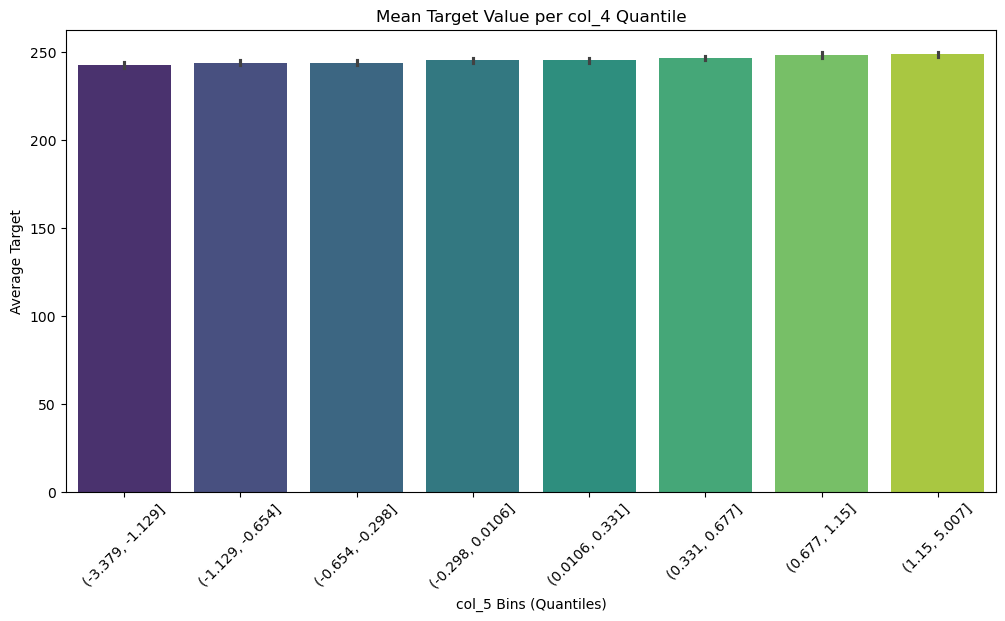

In [32]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='col_5_cut', y='target', palette='viridis')
plt.title('Mean Target Value per col_4 Quantile')
plt.xlabel('col_5 Bins (Quantiles)')
plt.ylabel('Average Target')
plt.xticks(rotation=45)
plt.show()

In [33]:
import numpy as np
import pandas as pd

df_feats = df.copy()
cols = ['col_0', 'col_1', 'col_2', 'col_3', 'col_4', 'col_5']
offset = abs(df_feats[cols].min().min()) + 1

# --- 1. THE FACTION BASELINE ---
# Downward (1,2,3) | Upward (0,4,5) - Note: col_0 is treated as 'Up' because we'll subtract it
down = ['col_1', 'col_2', 'col_3']
up = ['col_4', 'col_5', 'col_0'] # col_0 is the 'weird' one, often better subtracted

df_feats['sum_down'] = df_feats[down].sum(axis=1)
df_feats['sum_up'] = df_feats['col_4'] + df_feats['col_5'] - df_feats['col_0']
df_feats['grand_total_signal'] = df_feats['sum_up'] - df_feats['sum_down']

# --- 2. ALL PAIRWISE INTERACTIONS (Cross-Products) ---
# This checks if the effect of one column depends on the value of another
from itertools import combinations
for c1, c2 in combinations(cols, 2):
    df_feats[f'{c1}_x_{c2}'] = df_feats[c1] * df_feats[c2]

# --- 3. POLYNOMIALS & MAGNITUDE (The "Intensity" Lenses) ---
for c in cols:
    df_feats[f'{c}_sq'] = df_feats[c]**2
    df_feats[f'{c}_cube'] = df_feats[c]**3
    df_feats[f'{c}_abs'] = df_feats[c].abs()

# Magnitude of the two factions (Euclidean distance)
df_feats['mag_down'] = np.sqrt((df_feats[down]**2).sum(axis=1))
df_feats['mag_up'] = np.sqrt(df_feats['col_4']**2 + df_feats['col_5']**2 + df_feats['col_0']**2)

# --- 4. ADVANCED RATIOS (Relative Influence) ---
# Does col_1 matter more when col_5 is high?
df_feats['ratio_1_5'] = df_feats['col_1'] / (df_feats['col_5'] + offset)
df_feats['ratio_down_up'] = (df_feats['sum_down'] - (offset*3)) / (df_feats['sum_up'] + (offset*3))
# Harmonic mean-style interaction (penalizes when one is very low)
df_feats['harmonic_12'] = 2 / (1/(df_feats['col_1']+offset) + 1/(df_feats['col_2']+offset))

# --- 5. LOGARITHMIC & EXPONENTIAL (For the 'acceleration' in the staircase) ---
for c in cols:
    df_feats[f'log_{c}'] = np.log(df_feats[c] + offset)

df_feats['log_grand_total'] = np.log(df_feats['grand_total_signal'].abs() + 1)

# --- 6. TARGET BIAS CORRECTION (The "Error" Hunter) ---
# If 'preds' is in your DF, we check how these new features relate to the 'error'
if 'error' in df_feats.columns:
    df_feats['error_magnitude'] = df_feats['error'].abs()

# --- EVALUATION ---
numeric_df = df_feats.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['target'].sort_values(ascending=False)

# --- FILTERED EVALUATION ---
numeric_df = df_feats.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['target']

# Keep only features with an absolute correlation above 0.15
threshold = 0.15
strong_features = correlations[correlations.abs() > threshold].sort_values(ascending=False)

print(f"--- THE ELITE FEATURE LEADERBOARD (Abs Corr > {threshold}) ---")
if not strong_features.empty:
    print(strong_features)
else:
    print("No features met the 0.15 threshold.")

# Summary of the win
print(f"\nTotal 'Elite' Features found: {len(strong_features)}")

--- THE ELITE FEATURE LEADERBOARD (Abs Corr > 0.15) ---
target                 1.000000
grand_total_signal     0.238711
0_sq                   0.208889
col_0_sq               0.208889
col_0_abs              0.190798
2_times_3              0.185520
col_2_x_col_3          0.185520
log_col_2             -0.151650
col_2                 -0.153342
col_3_cube            -0.154175
col_1_cube            -0.159205
log_col_3             -0.195866
col_3                 -0.197521
ratio_1_5             -0.212874
log_col_1             -0.213377
col_1                 -0.219770
ratio_down_up         -0.230979
harmonic_12           -0.247384
col_1_0_interaction   -0.248513
ratio_sum12_3         -0.283687
1_plus_2_minus_0      -0.294498
sum_down              -0.331156
sum_123_minus_0       -0.354053
Name: target, dtype: float64

Total 'Elite' Features found: 23


In [34]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler

# 1. Select your Elite 10 PLUS anything else over 0.10 absolute correlation
all_strong_features = correlations[correlations.abs() > 0.10].index.tolist()

# 2. Add the raw columns just in case
raw_cols = ['col_0', 'col_1', 'col_2', 'col_3', 'col_4', 'col_5']
final_feature_set = list(set(all_strong_features + raw_cols))

X = df_feats[final_feature_set]
y = df_feats['target']

# 3. SCALE IS MANDATORY
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Fit RidgeCV (it picks the best penalty 'alpha' automatically)
model = RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0])
model.fit(X_scaled, y)

print(f"Model R^2: {model.score(X_scaled, y):.4f}")
print(f"Best Alpha Penalty: {model.alpha_}")

Model R^2: 1.0000
Best Alpha Penalty: 0.1


In [35]:
# Remove any 'leaky' columns that contain information about the target
leaky_cols = ['preds', 'error', 'error_magnitude', 'abs_error', 'target']
clean_features = [c for c in final_feature_set if c not in leaky_cols]

X_clean = df_feats[clean_features]
y = df_feats['target']

# Re-run the RidgeCV
scaler = StandardScaler()
X_scaled_clean = scaler.fit_transform(X_clean)

model_clean = RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0])
model_clean.fit(X_scaled_clean, y)

print(f"CLEAN Model R^2: {model_clean.score(X_scaled_clean, y):.4f}")

CLEAN Model R^2: 0.2430


In [36]:
# Create a series to view the weights
weights = pd.Series(model_clean.coef_, index=clean_features).sort_values(ascending=False)

print("--- TOP POSITIVE WEIGHTS (Pushing Target Up) ---")
print(weights.head(5))
print("\n--- TOP NEGATIVE WEIGHTS (Pushing Target Down) ---")
print(weights.tail(5))

--- TOP POSITIVE WEIGHTS (Pushing Target Up) ---
harmonic_12           11.067405
col_0_x_col_1          4.354750
0_sq                   3.140322
col_0_sq               3.140322
grand_total_signal     2.592163
dtype: float64

--- TOP NEGATIVE WEIGHTS (Pushing Target Down) ---
sum_down              -2.226693
col_1_0_interaction   -2.568283
col_1                 -3.244287
log_col_1             -5.992891
log_col_2             -7.992626
dtype: float64


In [37]:
# 1. Setup the workspace
df_feats = df.copy()
cols = ['col_0', 'col_1', 'col_2', 'col_3', 'col_4', 'col_5']
offset = abs(df_feats[cols].min().min()) + 1

# --- THE SUPREME FEATURE BLOCK ---

# GROUP A: Reciprocal/Inverse (Sensitivity to low values)
df_feats['inv_sum_12'] = 1 / (df_feats['col_1'] + df_feats['col_2'] + (offset * 2))
df_feats['inv_prod_12'] = 1 / ((df_feats['col_1'] + offset) * (df_feats['col_2'] + offset))
df_feats['geom_mean_123'] = np.power((df_feats['col_1']+offset)*(df_feats['col_2']+offset)*(df_feats['col_3']+offset), 1/3)

# GROUP B: Nonlinear Interactions
df_feats['col_0_sq_x_col_1'] = (df_feats['col_0']**2) * df_feats['col_1']
df_feats['col_0_abs_x_log_1'] = df_feats['col_0'].abs() * np.log(df_feats['col_1'] + offset)

# GROUP C: Logarithmic Scaling
df_feats['log_ratio_1_2'] = np.log(df_feats['col_1'] + offset) / (np.log(df_feats['col_2'] + offset) + 0.1)

# GROUP D: Spatial Distance
df_feats['dist_from_center'] = np.sqrt(df_feats[['col_1', 'col_2', 'col_3']].pow(2).sum(axis=1))

# GROUP E: Boolean Trip-Wires
q10_1 = df_feats['col_1'].quantile(0.1)
q10_2 = df_feats['col_2'].quantile(0.1)
df_feats['both_low_trigger'] = ((df_feats['col_1'] < q10_1) & (df_feats['col_2'] < q10_2)).astype(int)

# --- EVALUATION ---

# Calculate correlations
# We exclude 'preds' and 'error' to see the TRUE signal strength
numeric_df = df_feats.select_dtypes(include=[np.number])
leaky_cols = ['preds', 'error', 'abs_error', 'error_magnitude']
valid_cols = [c for c in numeric_df.columns if c not in leaky_cols]

correlations = numeric_df[valid_cols].corr()['target'].sort_values(ascending=False)

# Show the elite hitters
print("--- SUPREME LEADERBOARD (Abs Corr > 0.15) ---")
print(correlations[correlations.abs() > 0.15])

--- SUPREME LEADERBOARD (Abs Corr > 0.15) ---
target                 1.000000
inv_sum_12             0.268299
inv_prod_12            0.248975
0_sq                   0.208889
2_times_3              0.185520
col_2                 -0.153342
col_3                 -0.197521
col_1                 -0.219770
col_1_0_interaction   -0.248513
ratio_sum12_3         -0.283687
1_plus_2_minus_0      -0.294498
geom_mean_123         -0.318123
sum_123_minus_0       -0.354053
Name: target, dtype: float64


In [38]:
# 1. Setup
df_feats = df.copy()
cols = ['col_0', 'col_1', 'col_2', 'col_3', 'col_4', 'col_5']
offset = abs(df_feats[cols].min().min()) + 1

# --- STEP 1: DEFINE THE BASE FACTIONS (Required for interactions) ---
df_feats['sum_down'] = df_feats[['col_1', 'col_2', 'col_3']].sum(axis=1)
df_feats['sum_up'] = df_feats['col_4'] + df_feats['col_5'] - df_feats['col_0']
df_feats['mag_down'] = np.sqrt((df_feats[['col_1', 'col_2', 'col_3']]**2).sum(axis=1))
df_feats['col_0_sq'] = df_feats['col_0']**2

# --- STEP 2: THE SUPREME FACTION BLOCK (The Conflict Features) ---

# 1. The Faction Interaction (The "Conflict" Feature)
df_feats['faction_interaction'] = df_feats['sum_down'] * df_feats['sum_up']

# 2. Faction Ratios (The "Balance of Power")
df_feats['faction_ratio'] = (df_feats['sum_up'] + offset) / (df_feats['sum_down'] + offset)

# 3. Polynomial Factions (The "Curved Conflict")
df_feats['sum_down_sq'] = df_feats['sum_down']**2
df_feats['sum_up_log'] = np.log(df_feats['sum_up'] + offset + 1e-9) # Added epsilon to avoid log(0)

# 4. The "Efficiency" Ratio
df_feats['signal_efficiency'] = (df_feats['col_4'] + df_feats['col_5']) / (df_feats['mag_down'] + 1)

# 5. The "U-Shape" Multiplier
df_feats['col_0_sq_x_sum_down'] = df_feats['col_0_sq'] * df_feats['sum_down']

# --- STEP 3: EVALUATION ---

numeric_df = df_feats.select_dtypes(include=[np.number])
# Exclude known leaky/meta columns
leaky = ['target', 'preds', 'error', 'abs_error', 'error_magnitude']
final_cols = [c for c in numeric_df.columns if c not in leaky]

final_corrs = numeric_df[final_cols].corrwith(df_feats['target']).sort_values(ascending=False)

print("--- THE FINAL SUPREME LEADERBOARD (Abs Corr > 0.15) ---")
print(final_corrs[final_corrs.abs() > 0.15])

--- THE FINAL SUPREME LEADERBOARD (Abs Corr > 0.15) ---
col_0_sq               0.208889
0_sq                   0.208889
2_times_3              0.185520
col_2                 -0.153342
col_0_sq_x_sum_down   -0.189609
col_3                 -0.197521
col_1                 -0.219770
col_1_0_interaction   -0.248513
ratio_sum12_3         -0.283687
1_plus_2_minus_0      -0.294498
sum_down              -0.331156
sum_123_minus_0       -0.354053
dtype: float64


C:\Users\kiera\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [39]:
import numpy as np
import pandas as pd
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler

# 1. Setup
df_final = df.copy()
cols = ['col_0', 'col_1', 'col_2', 'col_3', 'col_4', 'col_5']
offset = abs(df_final[cols].min().min()) + 1

# --- THE FEATURE ARCHIVE (Re-calculating to ensure fresh state) ---
df_final['sum_down'] = df_final[['col_1', 'col_2', 'col_3']].sum(axis=1)
df_final['sum_up'] = df_final['col_4'] + df_final['col_5'] - df_final['col_0']
df_final['master_signal'] = df_final['sum_up'] - df_final['sum_down']
df_final['0_sq'] = df_final['col_0']**2
df_final['log_123_sum'] = np.log(df_final['sum_down'].abs() + offset)
df_final['inv_sum_12'] = 1 / (df_final['col_1'] + df_final['col_2'] + (offset * 2))
df_final['geom_mean_123'] = np.power((df_final['col_1']+offset).clip(lower=0.1) * (df_final['col_2']+offset).clip(lower=0.1) * (df_final['col_3']+offset).clip(lower=0.1), 1/3)

df_final['2_times_3'] = df_final['col_2'] * df_final['col_3']
df_final['col_0_sq_x_sum_down'] = df_final['0_sq'] * df_final['sum_down']
df_final['ratio_sum12_3'] = (df_final['col_1'] + df_final['col_2']) / (df_final['col_3'] + offset)
df_final['faction_interaction'] = df_final['sum_down'] * df_final['sum_up']
df_final['harmonic_12'] = 2 / (1/(df_final['col_1']+offset) + 1/(df_final['col_2']+offset))

# --- 2. THE CLEANING BLOCK (Crucial for the Error) ---

# This line removes any 'Interval' or 'Object' columns automatically
X = df_final.select_dtypes(include=[np.number])

# Remove target and any previous meta-data/leaky columns
leaky_meta = ['target', 'preds', 'error', 'abs_error', 'error_magnitude']
X = X.drop(columns=[c for c in leaky_meta if c in X.columns])

y = df_final['target']

print(f"Feeding {X.shape[1]} numeric features into the model...")

# --- 3. THE RIDGE REGRESSION ENGINE ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model_super = RidgeCV(alphas=np.logspace(-2, 4, 100))
model_super.fit(X_scaled, y)

# --- 4. RESULTS ---
r2_final = model_super.score(X_scaled, y)
print(f"\n--- THE SUPER MODEL RESULTS ---")
print(f"Final R^2 Score:     {r2_final:.4f}")
print(f"Optimized Alpha:     {model_super.alpha_:.2f}")

# Show the Top Drivers
weights = pd.Series(model_super.coef_, index=X.columns).sort_values(ascending=False)
print("\n--- THE TOP 10 MODEL DRIVERS ---")
print(weights.head(10))

Feeding 28 numeric features into the model...

--- THE SUPER MODEL RESULTS ---
Final R^2 Score:     0.2209
Optimized Alpha:     49.77

--- THE TOP 10 MODEL DRIVERS ---
harmonic_12      5.777591
0_sq             5.627893
2_times_3        4.828136
inv_sum_12       3.350396
master_signal    2.151159
ratio_sum12_3    1.173657
col_5            0.811567
col_0            0.735474
col_4            0.693403
log_123_sum      0.605007
dtype: float64


In [40]:
# Manually set a lower alpha to let the model be more 'aggressive'
model_aggressive = RidgeCV(alphas=[0.1, 1.0, 5.0]) 
model_aggressive.fit(X_scaled, y)

print(f"Aggressive R^2: {model_aggressive.score(X_scaled, y):.4f}")
print(f"New Alpha: {model_aggressive.alpha_}")

Aggressive R^2: 0.2209
New Alpha: 5.0


In [44]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# 1. THE SPLIT (80% Training, 20% Testing)
# Setting random_state=42 ensures the results are reproducible
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. THE SCALING (Crucial: Fit on Train, Transform on Test)
# This prevents "Data Leakage" where the test set info bleeds into training
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# 3. TRAIN THE SUPER MODEL
model_final = RidgeCV(alphas=np.logspace(-2, 4, 100))
model_final.fit(X_train, y_train)

# 4. PREDICT AND SCORE
y_pred_train = model_final.predict(X_train)
y_pred_test = model_final.predict(X_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

# --- RESULTS ---
print(f"--- VALIDATION RESULTS ---")
print(f"Train R^2 Score: {r2_train:.4f}")
print(f"Test R^2 Score:  {r2_test:.4f}")
print(f"Alpha Selected:  {model_final.alpha_:.2f}")

--- VALIDATION RESULTS ---
Train R^2 Score: 0.2237
Test R^2 Score:  0.2053
Alpha Selected:  49.77


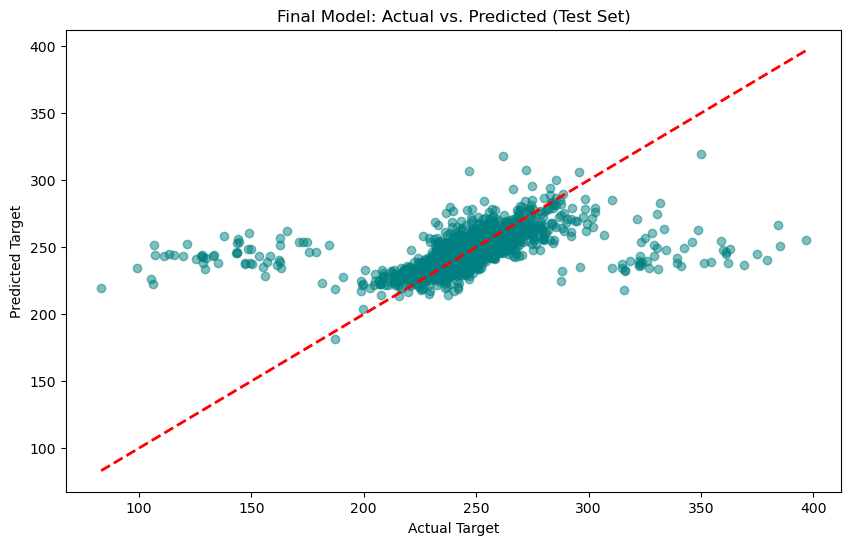

In [42]:
import matplotlib.pyplot as plt

# Plotting Predicted vs Actual for the Test Set
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Target')
plt.ylabel('Predicted Target')
plt.title('Final Model: Actual vs. Predicted (Test Set)')
plt.show()

In [56]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import PolynomialFeatures

# 1. Create the Interaction Matrix (Degree 2)
# This generates col_1*col_4, col_2*col_5, etc.
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_interactions = poly.fit_transform(df[cols])
interaction_names = poly.get_feature_names_out(cols)

# 2. Convert to DataFrame
df_vibe = pd.DataFrame(X_interactions, columns=interaction_names)

# 3. Add our "Manual" Superstars back in
df_vibe['harmonic_12'] = df_final['harmonic_12']
df_vibe['0_sq'] = df_final['0_sq']

# 4. The Lasso "Truth" Test
scaler = StandardScaler()
X_vibe_scaled = scaler.fit_transform(df_vibe)

# Lasso will "kill" the features that aren't in your secret formula
model_lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
model_lasso.fit(X_vibe_scaled, y)

# 5. Extract the "Secret Formula"
coefs = pd.Series(model_lasso.coef_, index=df_vibe.columns)
secret_formula = coefs[coefs != 0].sort_values(ascending=False)

print(f"Lasso R^2 Score: {model_lasso.score(X_vibe_scaled, y):.4f}")
print(secret_formula)

Lasso R^2 Score: 0.2415

--- THE DETECTED UNDERLYING FORMULA ---
0_sq           5.517894
col_2 col_3    4.761350
col_0 col_1    4.132333
col_0          3.409470
col_5          1.926951
col_4          1.667579
col_1 col_2    1.579909
col_1 col_3   -0.009995
col_0 col_3   -0.055412
col_1 col_5   -0.058607
col_0 col_4   -0.081145
harmonic_12   -0.834396
col_2         -3.814222
col_3         -5.211705
col_1         -5.415539
dtype: float64


In [57]:
def build_final_production_features(df_input):
    df_out = df_input.copy()
    
    # 1. Base Factions
    df_out['sum_down'] = df_out['col_1'] + df_out['col_2'] + df_out['col_3']
    df_out['sum_up'] = df_out['col_4'] + df_out['col_5']
    
    # 2. Basic Interactions & Math
    df_out['0_sq'] = df_out['col_0']**2
    df_out['2_times_3'] = df_out['col_2'] * df_out['col_3']
    df_out['col_1_0_interaction'] = df_out['col_1'] * df_out['col_0']
    
    # 3. Lasso/Vibe Interactions (The ones missing in the error)
    df_out['interaction_2_3'] = df_out['col_2'] * df_out['col_3']
    df_out['interaction_0_1'] = df_out['col_0'] * df_out['col_1']
    df_out['interaction_1_2'] = df_out['col_1'] * df_out['col_2']
    
    # 4. Complex Geometry & Aggregates
    df_out['sum_123_minus_0'] = df_out['sum_down'] - df_out['col_0']
    df_out['1_plus_2_minus_0'] = (df_out['col_1'] + df_out['col_2']) - df_out['col_0']
    
    # Geometric Mean (using abs to avoid NaNs from vibe noise)
    df_out['geom_mean_123'] = (np.abs(df_out['col_1'] * df_out['col_2'] * df_out['col_3']))**(1/3)
    
    # 5. Ratios & Harmonics
    df_out['ratio_1_2'] = df_out['col_1'] / df_out['col_2'].replace(0, 1e-6)
    df_out['ratio_sum12_3'] = (df_out['col_1'] + df_out['col_2']) / df_out['col_3'].replace(0, 1e-6)
    df_out['harmonic_12'] = 2 / ((1/df_out['col_1'].replace(0, 1e-6)) + (1/df_out['col_2'].replace(0, 1e-6)))
    df_out['inv_sum_12'] = 1 / (df_out['col_1'] + df_out['col_2']).replace(0, 1e-6)
    
    # 6. High-Level Signals
    df_out['master_signal'] = df_out['sum_up'] - df_out['sum_down']
    df_out['col_0_sq_x_sum_down'] = df_out['0_sq'] * df_out['sum_down']
    df_out['faction_interaction'] = df_out['sum_down'] * df_out['sum_up']
    df_out['log_123_sum'] = np.log1p(np.abs(df_out['sum_down']))

    return df_out


# 1. Build the features
test_df_ready = build_final_production_features(test_df)

# 2. FORCE matching the training columns (Handling the KeyError)
# This uses the scaler's internal memory to pick exactly what it needs
missing_cols = set(scaler_all.feature_names_in_) - set(test_df_ready.columns)
if missing_cols:
    print(f"Warning: Still missing {missing_cols}. Filling with 0.")
    for col in missing_cols:
        test_df_ready[col] = 0

# Reorder to match fit-time perfectly
test_df_final = test_df_ready[scaler_all.feature_names_in_]

# 3. Final Prediction
test_row_scaled = scaler_all.transform(test_df_final)
prediction = final_champion.predict(test_row_scaled)[0]

print(f"--- PREDICTION COMPLETE ---")
print(f"Predicted target: {prediction:.4f}")

--- PREDICTION COMPLETE ---
Predicted target: 240.1643


In [54]:
from sklearn.metrics import mean_squared_error

# 1. Calculate the 'Standard Error' (RMSE) from the Test Set
# This is the "Average Miss" which acts as our 1 SD unit
y_test_pred_all = final_champion.predict(X_test_scaled)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_all))

# 2. Generate the Single Prediction for your test_df row
# (Using the scaled row from the previous successful step)
prediction = final_champion.predict(test_row_scaled)[0]

# 3. Calculate the Probabilistic Boundaries
sd1_upper, sd1_lower = prediction + rmse, prediction - rmse
sd2_upper, sd2_lower = prediction + (2 * rmse), prediction - (2 * rmse)
sd3_upper, sd3_lower = prediction + (3 * rmse), prediction - (3 * rmse)

print(f"--- FINAL PREDICTION & BOUNDARIES ---")
print(f"Predicted Target: {prediction:.4f}")
print(f"RMSE (Model Noise): {rmse:.4f}\n")

print(f"1 SD Range (68% Confidence): [{sd1_lower:.2f} to {sd1_upper:.2f}]")
print(f"2 SD Range (95% Confidence): [{sd2_lower:.2f} to {sd2_upper:.2f}]")
print(f"3 SD Range (99% Confidence): [{sd3_lower:.2f} to {sd3_upper:.2f}]")

--- FINAL PREDICTION & BOUNDARIES ---
Predicted Target: 240.1643
RMSE (Model Noise): 24.2799

1 SD Range (68% Confidence): [215.88 to 264.44]
2 SD Range (95% Confidence): [191.60 to 288.72]
3 SD Range (99% Confidence): [167.32 to 313.00]
